# CCF Registration for Preprocessed RNAScope Data of Subregions

Prior to running this notebook, please first make sure that:
1. You have an overview image (lowres and or lowmag, as a `.czi` file) that is:
	1. Of a wide enough FOV to do the CCF registration with [QuickNII](https://www.nitrc.org/projects/quicknii) and [VisuAlign](https://www.nitrc.org/projects/visualign/)
	2. Cover your subregions of interest (your highres/highmag "data" images must be a subset/within the FOV of this overview image)
        1. **IMPORTANT!** If the overview image does not cover your subregions of interest, the CCF alignment mask (that based off of this overview image) will also miss your subregions!
	3. You did **not** physically move the slide under the scope in between imaging the overview and data images. All movements after taking the overview image must be done by moving the microscope stage via the micro-manipulator/software, as we will rely on the relative stage coordinates of the overview and data/subregion images to transform the data image coordinates into CCF space.
2. You have done the CCF registration of the **overview image** with QuickNII and VisuAlign, and have exported the aligned CCF mask as a `.flat` file from VisuAlign
3. You have run the preprocessing pipeline for your RNAScope data:
	1. Run the `imapose2vizgen` notebook/pipeline to convert the Imaris puncta `.csv` output, the Cellpose `.npy` output, and the raw highres subregion CZI image to the standardized, Vizgen-compatible outputs (`detected_transcripts.csv`, `cell_metadata.csv`, and `cell_by_gene.csv`)
	2. Run the `run_processing_pipeline.py` script to do the full preprocessing pipeline (qc, filter, etc.) to generate the final `*_filtered.hdf5` file that will be used as input for this notebook
	3. Repeat the preprocessing steps here for each of your subregions/data images



## Import + Layout Setup

In [1]:
import os, sys
from typing import Any, TypedDict, Literal, Union
import json
import warnings
import colorsys

# Suppress anndata internal FutureWarning about forward slashes in h5 keys
warnings.filterwarnings("ignore", category=FutureWarning, module="anndata")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import plotly.graph_objects as go
from PIL import Image as PILImage

plt.style.use("dark_background")
plt.rcParams.update({
    "figure.facecolor": "black",
    "axes.facecolor": "black",
    "savefig.facecolor": "black",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "legend.facecolor": "black",
    "legend.edgecolor": "white",
    "legend.labelcolor": "white",
})

import anndata
sys.path.append('../')
sys.path.append('../../')

with open("../../ref_data/Rainbow2017_AUD.json") as f:
    mask_metadata_raw = json.load(f)
# Normalize to dict keyed by CCF index (handles both list and dict formats)
if isinstance(mask_metadata_raw, list):
    mask_metadata = {i: entry for i, entry in enumerate(mask_metadata_raw)}
else:
    mask_metadata = mask_metadata_raw


---

## Paths Setup
Update the path to relevant files and directories here. The output directory will be created if it doesn't exist.

In [2]:
# The main data directory where raw data is saved
DATA_DIR = "D:/JOBS/WashU_Neuroscience/RNAScope/RNAScope_DATA/TEST_ACxDev1_CBA-CAJ_P18_Male_LACx_ONLY/data"
IMG_DIR = os.path.join(DATA_DIR, "images")

# Overview is the lowres/lowmag image that you used for CCF registration with QuickNII and VisuAlign
RAW_CZI_OVERVIEW = os.path.join(IMG_DIR, "P18LACx Layer1-6 tile overview.czi")
# "Subregions" are the highres data images
RAW_CZI_SUBREGIONS = [
    os.path.join(IMG_DIR, "P18LACx Layer1-6 40x.czi"),
]

# Preprocessed HDF5 files — one per subregion (from run_processing_pipeline.py)
# The order given here must match that in RAW_CZI_SUBREGIONS
PREPROCESSED_HDF5_SUBREGIONS = [
    os.path.join(DATA_DIR, "..", "analysis/RNAScope_CBA-CAJ_P18_filtered.hdf5")
]

# CCF aligned .flat files for the overview image
CCF_FLAT_OVERVIEW = os.path.join(DATA_DIR, "..", "analysis/CCF/aligned/P18LACx Layer1-6 tile overview_s0_nl.flat")

# Coordinate transform options (must match CCF registration)
flip_x = False # Whether the imaging was flipped left-right, so that we need to flip the data points/ref images here to match the CCF orientation
invert_hemi_labels = False

In [3]:
# The main folder to save your output files
OUTPUT_DIR = os.path.join(DATA_DIR, "..", "analysis")

# Your main HDF5 output for downstream analysis/stats
# This one file will include all subregions combined in the global overview coordinate system
# and include the registered CCF labels for all detected cells
OUTPUT_HDF5 = os.path.join(OUTPUT_DIR, "RNAScope_CBA-CAJ_P18_Male_withCCF.hdf5")


# This is a brief metadata file that describes the transformation used for mapping subregions onto the overview image
TRANSFORM_PARAMS_PATH = os.path.join(OUTPUT_DIR, "subregions2overview_transform_params.json")

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)

---

## Load CZI Metadata & Images

In [4]:
from czifile import CziFile
from pint import UnitRegistry
ureg = UnitRegistry()


class AxesInfo(TypedDict):
    pixels: int | None
    display_pixels: int | None
    offset_microns: float | None
    microns: float | None
    micron_per_pixel: float | None
    display_micron_per_pixel: float | None

class AxesMetadata(TypedDict):
    X: AxesInfo | None
    Y: AxesInfo | None

class CZIImage(TypedDict):
    xy_imgdata: np.ndarray | None
    axes_metadata: AxesMetadata


def default_axes_metadata() -> AxesMetadata:
    return AxesMetadata(X=None, Y=None)

def default_czi_image() -> CZIImage:
    return CZIImage(xy_imgdata=None, axes_metadata=default_axes_metadata())

def _jsonify_axes_info(ax_info: AxesInfo | None) -> dict | None:
    if ax_info is None:
        return None
    return {
        'pixels': None if ax_info['pixels'] is None else int(ax_info['pixels']),
        'display_pixels': None if ax_info['display_pixels'] is None else int(ax_info['display_pixels']),
        'offset_microns': None if ax_info['offset_microns'] is None else float(ax_info['offset_microns']),
        'microns': None if ax_info['microns'] is None else float(ax_info['microns']),
        'micron_per_pixel': None if ax_info['micron_per_pixel'] is None else float(ax_info['micron_per_pixel']),
        'display_micron_per_pixel': None if ax_info['display_micron_per_pixel'] is None else float(ax_info['display_micron_per_pixel']),
    }

class StagePosition(TypedDict):
    X: float
    Y: float

def czi_stage_position(czi: CziFile) -> StagePosition:
    """
        Extract stage position in microns from CZI metadata.
        Note that this is different from coord_offsets.
    """
    metadata = czi.metadata(asdict=True)
    scenes = metadata['ImageDocument']['Metadata']['Information']['Image']['Dimensions']['S']['Scenes']['Scene']
    scene_list = scenes if isinstance(scenes, list) else [scenes]
    scene = scene_list[0]
    coords = scene['CenterPosition']
    center_x = np.double(coords[0])
    center_y = np.double(coords[1])

    return StagePosition(X=center_x, Y=center_y)

axes_to_log = list(AxesMetadata.__annotations__.keys())

Some fixes to handle cases where somehow the file lost its absolute X/Y start origin, but still have a good subblock X/Y in its local origin

In [5]:
from typing import Any
import math


def _scene_list_from_metadata(metadata: dict) -> list[dict]:
    scenes = metadata["ImageDocument"]["Metadata"]["Information"]["Image"]["Dimensions"]["S"]["Scenes"]["Scene"]
    return scenes if isinstance(scenes, list) else [scenes]


def _scene_center_meters(czi: CziFile, scene_meta_index: int = 0) -> tuple[float, float] | None:
    """
    Scene CenterPosition is always in microns in the XML metadata, so convert to meters for comparison with coord_offsets.
    """
    try:
        metadata = czi.metadata(asdict=True)
        scene = _scene_list_from_metadata(metadata)[scene_meta_index]
        center_x_um, center_y_um = [float(v) for v in scene["CenterPosition"]]
        return center_x_um * 1e-6, center_y_um * 1e-6
    except Exception:
        return None


def consistent_coord_offsets(
    czi: CziFile,
    scene_key: int = 0,
    scene_meta_index: int = 0,
    tolerance_pixels: float = 8.0,
) -> tuple[dict[str, float], dict[str, Any]]:
    """
    Return coord_offsets-like dict in czifile units (meters for X/Y),
    plus diagnostics describing whether raw offsets or reconstructed
    offsets were used.
    """
    img = czi.scenes[scene_key]

    if "X" not in img.coord_scales or "Y" not in img.coord_scales:
        raw = dict(img.coord_offsets)
        return raw, {
            "source": "raw",
            "reason": "missing_xy_scales",
        }

    x_scale_m = float(img.coord_scales["X"])
    y_scale_m = float(img.coord_scales["Y"])
    x0_px, y0_px, width_px, height_px = img.bbox

    raw_x_m = x0_px * x_scale_m
    raw_y_m = y0_px * y_scale_m
    raw_offsets = {"X": raw_x_m, "Y": raw_y_m}

    center_m = _scene_center_meters(czi, scene_meta_index=scene_meta_index)
    if center_m is None:
        return raw_offsets, {
            "source": "raw",
            "reason": "missing_scene_center",
            "raw_offsets_m": raw_offsets,
        }

    center_x_m, center_y_m = center_m
    width_m = width_px * x_scale_m
    height_m = height_px * y_scale_m

    reconstructed_x_m = center_x_m - width_m / 2.0
    reconstructed_y_m = center_y_m - height_m / 2.0
    reconstructed_offsets = {"X": reconstructed_x_m, "Y": reconstructed_y_m}

    delta_x_px = abs(raw_x_m - reconstructed_x_m) / max(abs(x_scale_m), 1e-12)
    delta_y_px = abs(raw_y_m - reconstructed_y_m) / max(abs(y_scale_m), 1e-12)

    use_reconstructed = (
        not math.isfinite(raw_x_m)
        or not math.isfinite(raw_y_m)
        or delta_x_px > tolerance_pixels
        or delta_y_px > tolerance_pixels
    )

    chosen = reconstructed_offsets if use_reconstructed else raw_offsets

    return chosen, {
        "source": "scene_center_extent" if use_reconstructed else "raw_bbox",
        "raw_offsets_m": raw_offsets,
        "reconstructed_offsets_m": reconstructed_offsets,
        "delta_pixels": {"X": delta_x_px, "Y": delta_y_px},
        "bbox_px": {"X": x0_px, "Y": y0_px, "width": width_px, "height": height_px},
        "scale_m_per_px": {"X": x_scale_m, "Y": y_scale_m},
        "center_m": {"X": center_x_m, "Y": center_y_m},
    }


class StableCziScene:
    def __init__(
        self,
        czi: CziFile,
        scene_key: int = 0,
        scene_meta_index: int = 0,
        tolerance_pixels: float = 8.0,
    ) -> None:
        self._czi = czi
        self._scene_key = scene_key
        self._scene_meta_index = scene_meta_index
        self._tolerance_pixels = tolerance_pixels
        self._img = czi.scenes[scene_key]

    def __getattr__(self, name):
        return getattr(self._img, name)

    @property
    def coord_offsets(self) -> dict[str, float]:
        offsets, _ = consistent_coord_offsets(
            self._czi,
            scene_key=self._scene_key,
            scene_meta_index=self._scene_meta_index,
            tolerance_pixels=self._tolerance_pixels,
        )
        return offsets

    @property
    def coord_offsets_debug(self) -> dict[str, Any]:
        _, debug = consistent_coord_offsets(
            self._czi,
            scene_key=self._scene_key,
            scene_meta_index=self._scene_meta_index,
            tolerance_pixels=self._tolerance_pixels,
        )
        return debug


def flipCZIImage(xy_imgdata: np.ndarray | None, flip_x: bool) -> np.ndarray | None:
    """Mirror CZI display array horizontally when notebook flip_x is enabled."""
    if xy_imgdata is None or not flip_x:
        return xy_imgdata
    return np.ascontiguousarray(np.fliplr(xy_imgdata))


def flipAnnDataAgg(coords: Any, frame_width: float, flip_x: bool) -> np.ndarray:
    """Mirror AnnData spatial coords across frame width when notebook flip_x is enabled."""
    flipped = np.asarray(coords, dtype=np.float64).copy()
    if flip_x and flipped.size:
        flipped[:, 0] = frame_width - flipped[:, 0]
    return flipped


def flipRangeX(x0: float, x1: float, frame_width: float, flip_x: bool) -> tuple[float, float]:
    """Mirror [x0, x1] across frame width when notebook flip_x is enabled."""
    if not flip_x:
        return x0, x1
    return frame_width - x1, frame_width - x0


def flipCenterX(center_x: float, frame_width: float, flip_x: bool) -> float:
    """Mirror single x coordinate across frame width when notebook flip_x is enabled."""
    return frame_width - center_x if flip_x else center_x


In [ ]:
overview_czi_data = default_czi_image()
subregions_czi_data: dict[str, CZIImage] = {}


def _select_xy(img, z: int | Literal["best"] = "best", c: int | Literal["best", "max"] = "max") -> np.ndarray:
    """Select one XY slice.
    z can be a concrete Z index or "best".
    c can be a concrete channel, "best", or "max".
    "best" Z means the Z plane with the largest summed intensity across all channels.
    """

    def _read_plane(z_index: int | None = None, channel: int | None = None) -> np.ndarray:
        sel = {}
        for d in img.dims:
            if d == "Z":
                if z_index is not None:
                    sel[d] = z_index
            elif d == "C":
                if channel is not None:
                    sel[d] = channel
            elif d not in ("Y", "X"):
                sel[d] = 0
        return img(**sel).asarray()

    def _score_z(z_index: int) -> float:
        if "C" not in img.dims:
            plane = _read_plane(z_index=z_index)
            return float(np.sum(plane, dtype=np.float64))

        total = 0.0
        for ci in range(img.sizes["C"]):
            plane = _read_plane(z_index=z_index, channel=ci)
            total += float(np.sum(plane, dtype=np.float64))
        return total

    if "Z" in img.dims:
        z_index = max(range(img.sizes["Z"]), key=_score_z) if z == "best" else z
    else:
        z_index = None

    if "C" not in img.dims:
        return _read_plane(z_index=z_index)

    if c == "best":
        best_c = max(
            range(img.sizes["C"]),
            key=lambda ci: float(np.sum(_read_plane(z_index=z_index, channel=ci), dtype=np.float64)),
        )
        return _read_plane(z_index=z_index, channel=best_c)

    if c == "max":
        max_plane = None
        for ci in range(img.sizes["C"]):
            plane = _read_plane(z_index=z_index, channel=ci)
            if max_plane is None:
                max_plane = plane
            else:
                np.maximum(max_plane, plane, out=max_plane)
        assert max_plane is not None, "No channels found in image"
        return max_plane

    return _read_plane(z_index=z_index, channel=c)


def _make_axes_info(imgraw, img_level, ax: str, offsets) -> AxesInfo:
    ax_index_raw = imgraw.dims.index(ax)
    ax_index_level = img_level.dims.index(ax)
    scale = imgraw.coord_scales[ax] * ureg(imgraw.coord_units[ax])
    micron_per_pixel = scale.to("micron").magnitude
    size_pixels = imgraw.shape[ax_index_raw]
    size_microns = size_pixels * micron_per_pixel
    display_pixels = img_level.shape[ax_index_level]
    display_micron_per_pixel = size_microns / display_pixels
    return AxesInfo(
        pixels=size_pixels,
        display_pixels=display_pixels,
        offset_microns=offsets[ax] * ureg(imgraw.coord_units[ax]).to("micron").magnitude,
        microns=size_microns,
        micron_per_pixel=micron_per_pixel,
        display_micron_per_pixel=display_micron_per_pixel,
    )


# --- Load overview ---
with CziFile(RAW_CZI_OVERVIEW) as czi:
    imgraw = StableCziScene(czi, scene_key=0)
    shaperaw = imgraw.shape
    offsets = imgraw.coord_offsets
    nlevels = len(imgraw.levels)
    level_index = nlevels * 3 // 6 if nlevels > 2 else 0
    img = imgraw.levels[level_index]

    overview_czi_data['xy_imgdata'] = flipCZIImage(_select_xy(img), flip_x)

    for ax in axes_to_log:
        if ax not in imgraw.dims:
            continue
        overview_czi_data['axes_metadata'][ax] = _make_axes_info(imgraw, img, ax, offsets)

# --- Load subregions ---
for subregion_czi_path in RAW_CZI_SUBREGIONS:
    with CziFile(subregion_czi_path) as czi:
        imgraw = StableCziScene(czi, scene_key=0)
        shaperaw = imgraw.shape
        offsets = imgraw.coord_offsets
        nlevels = len(imgraw.levels)
        level_index = nlevels * 5 // 6 if nlevels > 2 else 0
        img = imgraw.levels[level_index]

        subregion_data = default_czi_image()
        subregion_data['xy_imgdata'] = flipCZIImage(_select_xy(img), flip_x)

        for ax in axes_to_log:
            if ax not in imgraw.dims:
                continue
            subregion_data['axes_metadata'][ax] = _make_axes_info(imgraw, img, ax, offsets)

        subregions_czi_data[subregion_czi_path] = subregion_data

print(f"Loaded overview + {len(subregions_czi_data)} subregion(s)")


Loaded overview + 1 subregion(s)


## Subregions -> Overview Alignment

In [7]:
# Save transform params
ov_xm = overview_czi_data['axes_metadata']['X']
ov_ym = overview_czi_data['axes_metadata']['Y']
# Assert that we have the necessary metadata to compute offsets
assert ov_xm is not None and ov_ym is not None, "Missing axes metadata for overview image; cannot compute offsets"
assert ov_xm['offset_microns'] is not None and ov_ym['offset_microns'] is not None, "Missing offset metadata for overview image; cannot compute offsets"

ov_x_off = float(ov_xm['offset_microns'])
ov_y_off = float(ov_ym['offset_microns'])

transform_params = {
    'overview': {
        'czi_path': RAW_CZI_OVERVIEW,
        'origin_microns': {'X': 0.0, 'Y': 0.0},
        'absolute_offset_microns': {'X': ov_x_off, 'Y': ov_y_off},
        'flip_x': flip_x,
        'axes_metadata': {
            'X': _jsonify_axes_info(ov_xm),
            'Y': _jsonify_axes_info(ov_ym),
        },
    },
    'subregions': [],
}

for subregion_czi_path, sr in subregions_czi_data.items():
    sr_xm = sr['axes_metadata']['X']
    sr_ym = sr['axes_metadata']['Y']
    assert sr_xm is not None and sr_ym is not None, f"Missing axes metadata for subregion image {subregion_czi_path}; cannot compute offsets"
    assert sr_xm['offset_microns'] is not None and sr_ym['offset_microns'] is not None, f"Missing offset metadata for subregion image {subregion_czi_path}; cannot compute offsets"
    assert sr_xm['pixels'] is not None and sr_xm['micron_per_pixel'] is not None and sr_ym['pixels'] is not None and sr_ym['micron_per_pixel'] is not None, f"Missing pixel or micron_per_pixel metadata for subregion image {subregion_czi_path}; cannot compute physical size"
    
    sr_x_off = float(sr_xm['offset_microns'])
    sr_y_off = float(sr_ym['offset_microns'])
    rel_x = sr_x_off - ov_x_off
    rel_y = sr_y_off - ov_y_off
    sr_width = float(sr_xm['pixels']) * float(sr_xm['micron_per_pixel'])
    sr_height = float(sr_ym['pixels']) * float(sr_ym['micron_per_pixel'])
    transform_params['subregions'].append({
        'czi_path': subregion_czi_path,
        'relative_offset_microns': {'X': rel_x, 'Y': rel_y},
        'absolute_offset_microns': {'X': sr_x_off, 'Y': sr_y_off},
        'flip_x': flip_x,
        'extent_microns': {
            'left': rel_x, 'right': rel_x + sr_width,
            'top': rel_y, 'bottom': rel_y + sr_height,
        },
        'axes_metadata': {
            'X': _jsonify_axes_info(sr_xm),
            'Y': _jsonify_axes_info(sr_ym),
        },
    })

with open(TRANSFORM_PARAMS_PATH, 'w', encoding='utf-8') as fh:
    json.dump(transform_params, fh, indent=2)

print(f'Saved transform params to: {TRANSFORM_PARAMS_PATH}')


Saved transform params to: D:/JOBS/WashU_Neuroscience/RNAScope/RNAScope_DATA/TEST_ACxDev1_CBA-CAJ_P18_Male_LACx_ONLY/data\..\analysis\subregions2overview_transform_params.json


In [8]:
def get_subregion_hsl_color(index: int, total: int) -> tuple[float, float, float]:
    hue = index / max(total, 1)
    return colorsys.hls_to_rgb(hue, 0.78, 1.0)


def style_dark_axes(ax, title: str | None = None, show_origin_axes: bool = False) -> None:
    ax.set_facecolor("black")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    ax.tick_params(colors="white")
    for spine in ax.spines.values():
        spine.set_color("white")
    if title is not None:
        ax.set_title(title, color="white")
    if show_origin_axes:
        ax.axhline(0, color="white", linewidth=1, alpha=0.5)
        ax.axvline(0, color="white", linewidth=1, alpha=0.5)


def style_dark_legend(legend) -> None:
    if legend is None:
        return
    frame = legend.get_frame()
    frame.set_facecolor("black")
    frame.set_edgecolor("white")
    for text in legend.get_texts():
        text.set_color("white")


def get_overview_plot_bounds() -> dict[str, float]:
    bounds = {
        "left": 0.0,
        "right": float(overview_czi_data["axes_metadata"]["X"]["microns"]), # type: ignore
        "top": 0.0,
        "bottom": float(overview_czi_data["axes_metadata"]["Y"]["microns"]), # type: ignore
    }
    overview_w = float(overview_czi_data["axes_metadata"]["X"]["microns"]) # type: ignore
    for entry in transform_params["subregions"]:
        extent = entry["extent_microns"]
        x0, x1 = flipRangeX(float(extent["left"]), float(extent["right"]), overview_w, flip_x)
        bounds["left"] = min(bounds["left"], x0)
        bounds["right"] = max(bounds["right"], x1)
        bounds["top"] = min(bounds["top"], float(extent["top"]))
        bounds["bottom"] = max(bounds["bottom"], float(extent["bottom"]))
    return bounds


In [9]:
from matplotlib.figure import Figure
def pad_axes(fig: Union[Figure, go.Figure], pad_fraction: float = 0.05) -> None:
    """
        Add padding to the axes limits of a Matplotlib or Plotly figure by a fraction of the total width/height.
        If a figure has multiple subplots, the same padding will be applied to all of them.
    """
    if isinstance(fig, Figure):
        for ax in fig.axes:
            x_lo, x_hi = ax.get_xlim()
            y_lo, y_hi = ax.get_ylim()
            x_span = x_hi - x_lo
            y_span = y_hi - y_lo
            ax.set_xlim(x_lo - pad_fraction * x_span, x_hi + pad_fraction * x_span)
            ax.set_ylim(y_lo - pad_fraction * y_span, y_hi + pad_fraction * y_span)
    elif isinstance(fig, go.Figure):
        layout = fig.to_plotly_json().get("layout", {})
        updates = {}
        for key in layout:
            if key.startswith("xaxis") or key.startswith("yaxis"):
                axis = layout[key]
                if isinstance(axis, dict) and "range" in axis and axis["range"] is not None:
                    r = axis["range"]
                    if len(r) == 2:
                        span = r[1] - r[0]
                        updates[key] = {
                            "range": [r[0] - pad_fraction * span, r[1] + pad_fraction * span]
                        }
        if updates:
            fig.update_layout(**updates)

In [10]:
# Quick validation + export — overview with subregions alpha-blended using dynamic HSL colors
ov = overview_czi_data
xm = ov["axes_metadata"]["X"]
ym = ov["axes_metadata"]["Y"]

overview_w = float(xm["pixels"]) * float(xm["micron_per_pixel"]) # type: ignore
overview_h = float(ym["pixels"]) * float(ym["micron_per_pixel"]) # type: ignore
overview_display_mpp_x = overview_w / ov["xy_imgdata"].shape[1] # type: ignore
overview_display_mpp_y = overview_h / ov["xy_imgdata"].shape[0] # type: ignore
overview_bounds = get_overview_plot_bounds()

data = ov["xy_imgdata"].astype(np.float32) # type: ignore
data_min, data_max = data.min(), data.max()
data_norm = (data - data_min) / (data_max - data_min + 1e-12)
data_norm = np.power(data_norm, 0.9)

base_gray = np.clip(data_norm * 255, 0, 255).astype(np.uint8)
x_span = overview_bounds["right"] - overview_bounds["left"]
y_span = overview_bounds["bottom"] - overview_bounds["top"]
canvas_width = max(1, int(np.ceil(x_span / overview_display_mpp_x)))
canvas_height = max(1, int(np.ceil(y_span / overview_display_mpp_y)))
composite = np.zeros((canvas_height, canvas_width, 3), dtype=np.float32)
overview_left_idx = max(0, int(round((0.0 - overview_bounds["left"]) / overview_display_mpp_x)))
overview_top_idx = max(0, int(round((0.0 - overview_bounds["top"]) / overview_display_mpp_y)))
overview_bottom_idx = min(canvas_height, overview_top_idx + base_gray.shape[0])
overview_right_idx = min(canvas_width, overview_left_idx + base_gray.shape[1])
composite[overview_top_idx:overview_bottom_idx, overview_left_idx:overview_right_idx] = np.stack([base_gray] * 3, axis=-1)[:overview_bottom_idx-overview_top_idx, :overview_right_idx-overview_left_idx].astype(np.float32)

inline_width_px = 1100
inline_height_px = max(1, int(round(inline_width_px * (y_span / x_span))))
export_width_px = 3000
export_height_px = max(1, int(round(export_width_px * (y_span / x_span))))

ov_x_off = float(xm["offset_microns"]) # type: ignore
ov_y_off = float(ym["offset_microns"]) # type: ignore
n_sr = len(subregions_czi_data)
rect_shapes = []

for i, (path, sr) in enumerate(subregions_czi_data.items()):
    sr_xm = sr["axes_metadata"]["X"]
    sr_ym = sr["axes_metadata"]["Y"]
    sr_left = float(sr_xm["offset_microns"]) - ov_x_off # type: ignore
    sr_right = sr_left + float(sr_xm["pixels"]) * float(sr_xm["micron_per_pixel"]) # type: ignore
    sr_bottom = (float(sr_ym["offset_microns"]) - ov_y_off) + float(sr_ym["pixels"]) * float(sr_ym["micron_per_pixel"]) # type: ignore
    sr_top = float(sr_ym["offset_microns"]) - ov_y_off # type: ignore

    sr_data = sr["xy_imgdata"].astype(np.float32) # type: ignore
    sr_max = sr_data.max()
    p_low = np.percentile(sr_data, 5)
    sr_norm = (sr_data - p_low) / (sr_max - p_low + 1e-12)
    sr_norm = np.clip(sr_norm, 0, 1)
    sr_norm = np.power(sr_norm, 0.45)

    r, g, b = get_subregion_hsl_color(i, n_sr)
    color = np.array([r, g, b], dtype=np.float32)
    line_color = f"rgb({int(r * 255)}, {int(g * 255)}, {int(b * 255)})"

    alpha_map = 0.95 * np.power(sr_norm, 0.7)

    sr_left_vis, sr_right_vis = flipRangeX(sr_left, sr_right, overview_w, flip_x)
    target_left = max(0, int(round((sr_left_vis - overview_bounds["left"]) / overview_display_mpp_x)))
    target_right = min(composite.shape[1], int(round((sr_right_vis - overview_bounds["left"]) / overview_display_mpp_x)))
    target_top = max(0, int(round((sr_top - overview_bounds["top"]) / overview_display_mpp_y)))
    target_bottom = min(composite.shape[0], int(round((sr_bottom - overview_bounds["top"]) / overview_display_mpp_y)))

    target_width = target_right - target_left
    target_height = target_bottom - target_top
    if target_width <= 0 or target_height <= 0:
        continue

    sr_norm_img = PILImage.fromarray(np.clip(sr_norm * 255, 0, 255).astype(np.uint8))
    alpha_img = PILImage.fromarray(np.clip(alpha_map * 255, 0, 255).astype(np.uint8))
    resized_norm = np.asarray(
        sr_norm_img.resize((target_width, target_height), PILImage.Resampling.BILINEAR),
        dtype=np.float32,
    ) / 255.0
    resized_alpha = np.asarray(
        alpha_img.resize((target_width, target_height), PILImage.Resampling.BILINEAR),
        dtype=np.float32,
    ) / 255.0

    overlay_rgb = resized_norm[..., None] * color * 255.0
    alpha_rgb = resized_alpha[..., None]
    region = composite[target_top:target_bottom, target_left:target_right]
    composite[target_top:target_bottom, target_left:target_right] = region * (1.0 - alpha_rgb) + overlay_rgb * alpha_rgb

    rect_shapes.append({
        "type": "rect",
        "x0": sr_left_vis,
        "x1": sr_right_vis,
        "y0": sr_top,
        "y1": sr_bottom,
        "line": {"color": line_color, "width": 3},
        "fillcolor": "rgba(0, 0, 0, 0)",
    })

display_img = np.clip(composite, 0, 255).astype(np.uint8)

fig = go.Figure()
fig.add_trace(
    go.Image(
        z=display_img,
        name="Overview + Subregions",
        x0=overview_bounds["left"],
        dx=overview_display_mpp_x,
        y0=overview_bounds["top"],
        dy=overview_display_mpp_y,
    )
)
fig.update_layout(
    title="Overview + Subregions",
    width=inline_width_px,
    height=inline_height_px,
    margin=dict(l=60, r=20, t=50, b=60),
    paper_bgcolor="black",
    plot_bgcolor="black",
    font=dict(color="white"),
    shapes=rect_shapes,
    xaxis=dict(
        title="X (um)",
        range=[overview_bounds["left"], overview_bounds["right"]],
        showgrid=False,
        zeroline=False,
        color="white",
    ),
    yaxis=dict(
        title="Y (um)",
        range=[overview_bounds["bottom"], overview_bounds["top"]],
        showgrid=False,
        zeroline=False,
        scaleanchor="x",
        scaleratio=1,
        color="white",
    ),
)




print(f"Loaded overview + {len(subregions_czi_data)} subregion(s)")
# Dimension pixel stats
print("Overview dimensions:")
for ax in axes_to_log:
	ax_info = overview_czi_data['axes_metadata'][ax]
	if ax_info is not None:
		print(f"  {ax}: full={ax_info['pixels']} px, display={ax_info['display_pixels']} px, {ax_info['microns']:.2f} microns, full={ax_info['micron_per_pixel']:.4f} micron/pixel, display={ax_info['display_micron_per_pixel']:.4f} micron/pixel, offset {ax_info['offset_microns']:.2f} microns")
	else:
		print(f"  {ax}: not found in overview")

print("Subregion dimensions:")
for subregion_path, subregion_data in subregions_czi_data.items():
	print(f"  {os.path.basename(subregion_path)}:")
	for ax in axes_to_log:
		ax_info = subregion_data['axes_metadata'][ax]
		if ax_info is not None:
			print(f"    {ax}: full={ax_info['pixels']} px, display={ax_info['display_pixels']} px, {ax_info['microns']:.2f} microns, full={ax_info['micron_per_pixel']:.4f} micron/pixel, display={ax_info['display_micron_per_pixel']:.4f} micron/pixel, offset {ax_info['offset_microns']:.2f} microns")
		else:
			print(f"    {ax}: not found in subregion")

fig.show()

imgoutpath = os.path.normpath(os.path.join(OUTPUT_DIR, "subregions2overview_alignment.webp"))
fig.write_image(
    imgoutpath,
    format="webp",
    width=export_width_px,
    height=export_height_px,
)
			
print(f"Saved to: {imgoutpath}")


Loaded overview + 1 subregion(s)
Overview dimensions:
  X: full=2912 px, display=728 px, 2628.79 microns, full=0.9027 micron/pixel, display=3.6110 micron/pixel, offset -71507.25 microns
  Y: full=2549 px, display=638 px, 2301.09 microns, full=0.9027 micron/pixel, display=3.6067 micron/pixel, offset -7250.84 microns
Subregion dimensions:
  P18LACx Layer1-6 40x.czi:
    X: full=37273 px, display=1165 px, 1930.37 microns, full=0.0518 micron/pixel, display=1.6570 micron/pixel, offset -70899.18 microns
    Y: full=11469 px, display=359 px, 593.98 microns, full=0.0518 micron/pixel, display=1.6545 micron/pixel, offset -6591.75 microns


Saved to: D:\JOBS\WashU_Neuroscience\RNAScope\RNAScope_DATA\TEST_ACxDev1_CBA-CAJ_P18_Male_LACx_ONLY\analysis\subregions2overview_alignment.webp


## Load and Aggregate Subregion HDF5 Data

Combine all HDF5 subregions. For each subregion, flip and add the relative offset (subregion → overview) so all cells share a single global coordinate system anchored at the overview origin.

In [11]:
# For RNAScope data, rotation is always off!
rotation_deg = 0.0

In [12]:
# Build a per-subregion offset lookup from subregion CZI path -> (rel_x, rel_y)
ov_x_off = float(overview_czi_data['axes_metadata']['X']['offset_microns']) # type: ignore
ov_y_off = float(overview_czi_data['axes_metadata']['Y']['offset_microns']) # type: ignore
ov_width = float(overview_czi_data['axes_metadata']['X']['microns']) # type: ignore

subregion_offsets: dict[str, tuple[float, float]] = {}
for entry in transform_params['subregions']:
    subregion_offsets[entry['czi_path']] = (
        entry['relative_offset_microns']['X'],
        entry['relative_offset_microns']['Y'],
    )

# Aggregate all subregion AnnDatas into one
aggregated_parts: list[anndata.AnnData] = []

for i, (subregion_path, hdf5_path) in enumerate(zip(RAW_CZI_SUBREGIONS, PREPROCESSED_HDF5_SUBREGIONS)):
    adata = anndata.read_h5ad(hdf5_path)
    coords = adata.obsm["spatial"].copy()
    adata.obsm["spatial_local"] = coords.copy()

    # Translate subregion-local coords into overview-global coords
    rel_x, rel_y = subregion_offsets[subregion_path]
    coords[:, 0] += rel_x
    coords[:, 1] += rel_y

    # Mirror final overview-global x coords when notebook flip_x is enabled
    coords = flipAnnDataAgg(coords, ov_width, flip_x)

    adata.obsm["spatial"] = coords
    
	# Keep obs center coordinates in the same global coordinate system
    adata.obs["center_x_local"] = adata.obs["center_x"].to_numpy()
    adata.obs["center_y_local"] = adata.obs["center_y"].to_numpy()

    adata.obs["center_x"] = coords[:, 0]
    adata.obs["center_y"] = coords[:, 1]

    adata.obs["subregion_idx"] = i  # tag cells by subregion origin for plotting
    aggregated_parts.append(adata)
    print(f"Subregion {i}: {adata.n_obs} cells -> global coords (offset {rel_x:.0f}, {rel_y:.0f})")

# Concatenate all subregions
adata = anndata.concat(aggregated_parts, axis=0, join="outer", uns_merge="first")
print(f"\nAggregated AnnData: {adata.n_obs} cells total")


Subregion 0: 3041 cells -> global coords (offset 608, 659)

Aggregated AnnData: 3041 cells total


### QC: Per-Subregion Detected Cells on Subregion Image

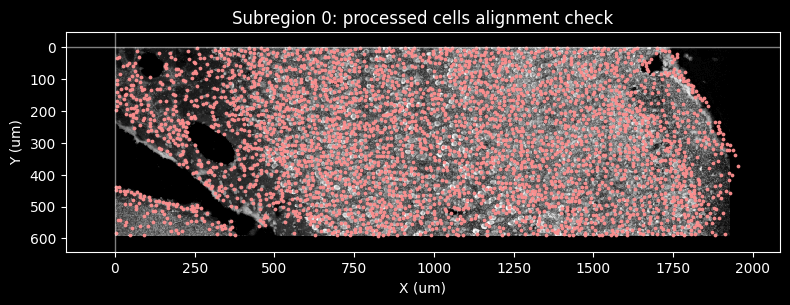

In [13]:
# Plot all subregions in a vertical tiled layout with dynamic HSL scatter colors
n_subregions = len(RAW_CZI_SUBREGIONS)
if n_subregions == 0:
    raise ValueError("RAW_CZI_SUBREGIONS is empty.")

fig, axes = plt.subplots(
    nrows=n_subregions,
    ncols=1,
    figsize=(8, max(4, 5 * n_subregions)),
    squeeze=False,
)
axes = axes.ravel()

for i, subregion_path in enumerate(RAW_CZI_SUBREGIONS):
    ax = axes[i]

    # Get coordinates for this subregion from the aggregated AnnData
    sub_coords = adata[adata.obs["subregion_idx"] == i].obsm["spatial_local"].copy()

    # Background image + spatial scale
    subregion = subregions_czi_data[subregion_path]
    subregion_img = subregion["xy_imgdata"].astype(np.float32) # type: ignore

    subregion_x = subregion["axes_metadata"]["X"]
    subregion_y = subregion["axes_metadata"]["Y"]
    subregion_width = float(subregion_x["pixels"]) * float(subregion_x["micron_per_pixel"]) # type: ignore
    subregion_height = float(subregion_y["pixels"]) * float(subregion_y["micron_per_pixel"]) # type: ignore

    # Mirror preview coordinates in same frame as CZI image
    sub_coords = flipAnnDataAgg(sub_coords, subregion_width, flip_x)

    # Contrast enhancement for dim CZI
    subregion_log = np.log1p(subregion_img)
    display_low, display_high = np.percentile(subregion_log, [3, 100])
    subregion_display = np.clip(
        (subregion_log - display_low) / (display_high - display_low + 1e-12),
        0.0,
        1.0,
    )
    subregion_display = np.power(subregion_display, 1.5)

    scatter_color = get_subregion_hsl_color(i, n_subregions)

    # Draw background and points
    ax.imshow(
        subregion_display,
        cmap="gray",
        extent=(0.0, subregion_width, subregion_height, 0.0),
        interpolation="nearest",
    )
    ax.scatter(sub_coords[:, 0], sub_coords[:, 1], s=3, c=[scatter_color], alpha=0.9)

    ax.set_xlim(0.0, subregion_width)
    ax.set_ylim(subregion_height, 0.0)
    ax.set_aspect("equal", "box")
    ax.set_xlabel("X (um)")
    ax.set_ylabel("Y (um)")
    style_dark_axes(ax, f"Subregion {i}: processed cells alignment check", show_origin_axes=True)

pad_axes(fig, pad_fraction=0.08)
plt.tight_layout()
plt.show()


### QC: Aggregate AnnData on Overview Image

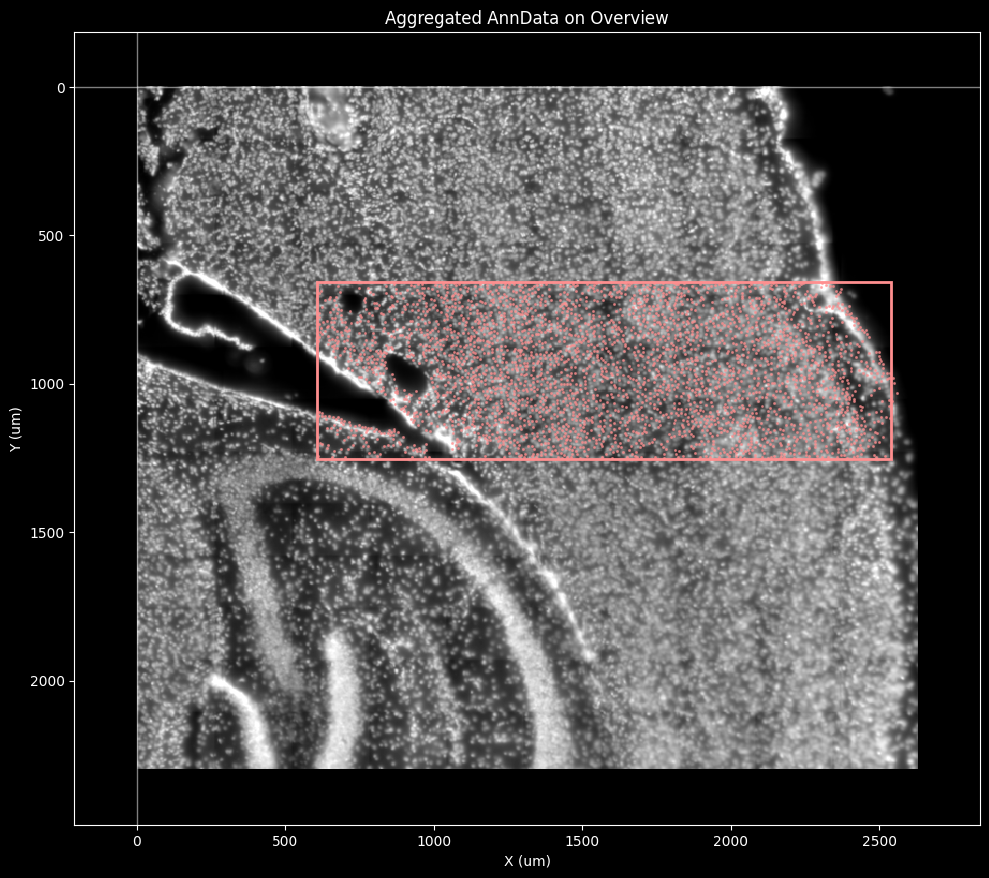

In [ ]:
overview_img = overview_czi_data["xy_imgdata"].astype(np.float32)  # type: ignore
overview_x = overview_czi_data["axes_metadata"]["X"]
overview_y = overview_czi_data["axes_metadata"]["Y"]
overview_width = float(overview_x["pixels"]) * float(overview_x["micron_per_pixel"]) # type: ignore
overview_height = float(overview_y["pixels"]) * float(overview_y["micron_per_pixel"]) # type: ignore
overview_bounds = get_overview_plot_bounds()

# Enhance overview contrast
ov_log = np.log1p(overview_img)
ov_low, ov_high = np.percentile(ov_log, [3, 99.8])
ov_display = np.clip((ov_log - ov_low) / (ov_high - ov_low + 1e-12), 0.0, 1.0)
ov_display = np.power(ov_display, 1.8)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(
    ov_display,
    cmap="gray",
    extent=(0.0, overview_width, overview_height, 0.0),
    interpolation="nearest",
)

# Color each subregion's cells with its unique HSL hue
n_subregions = len(RAW_CZI_SUBREGIONS)
for i in range(n_subregions):
    sub_coords = adata[adata.obs["subregion_idx"] == i].obsm["spatial"].copy()
    scatter_color = get_subregion_hsl_color(i, n_subregions)
    ax.scatter(sub_coords[:, 0], sub_coords[:, 1], s=1.2, c=[scatter_color], alpha=0.55)

# Draw subregion boundaries with the matching HSL color
for i, entry in enumerate(transform_params["subregions"]):
    e = entry["extent_microns"]
    boundary_color = get_subregion_hsl_color(i, n_subregions)
    x0, x1 = flipRangeX(float(e["left"]), float(e["right"]), overview_width, flip_x)
    rect = Rectangle(
        (x0, e["top"]),
        x1 - x0,
        e["bottom"] - e["top"],
        fill=False,
        edgecolor=boundary_color,
        linewidth=2,
    )
    ax.add_patch(rect)

ax.set_xlim(overview_bounds["left"], overview_bounds["right"])
ax.set_ylim(overview_bounds["bottom"], overview_bounds["top"])
ax.set_aspect("equal", "box")
ax.set_xlabel("X (um)")
ax.set_ylabel("Y (um)")
style_dark_axes(ax, "Aggregated AnnData on Overview", show_origin_axes=True)
pad_axes(fig, pad_fraction=0.08)
plt.tight_layout()
plt.show()

# Save the figure
imgoutpath = os.path.normpath(os.path.join(OUTPUT_DIR, "aggAnndata2overview_alignment.webp"))
fig.savefig(
    imgoutpath,
    format="webp",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.15,
)
print(f"Saved to: {imgoutpath}")

## Overview -> CCF Alignment

### Set Hemisphere Midline `center_x`
Change the `center_x` and the `center_x_offset` here to adjust the hemisphere midline for assigning left vs. right hemisphere labels in the CCF. Rerun this cell to preview the new midline overlaid on the overview image.

center_x_local = 2639.8 um
center_x = 2639.8 um  (overview width = 2628.8 um, flip_x=False)


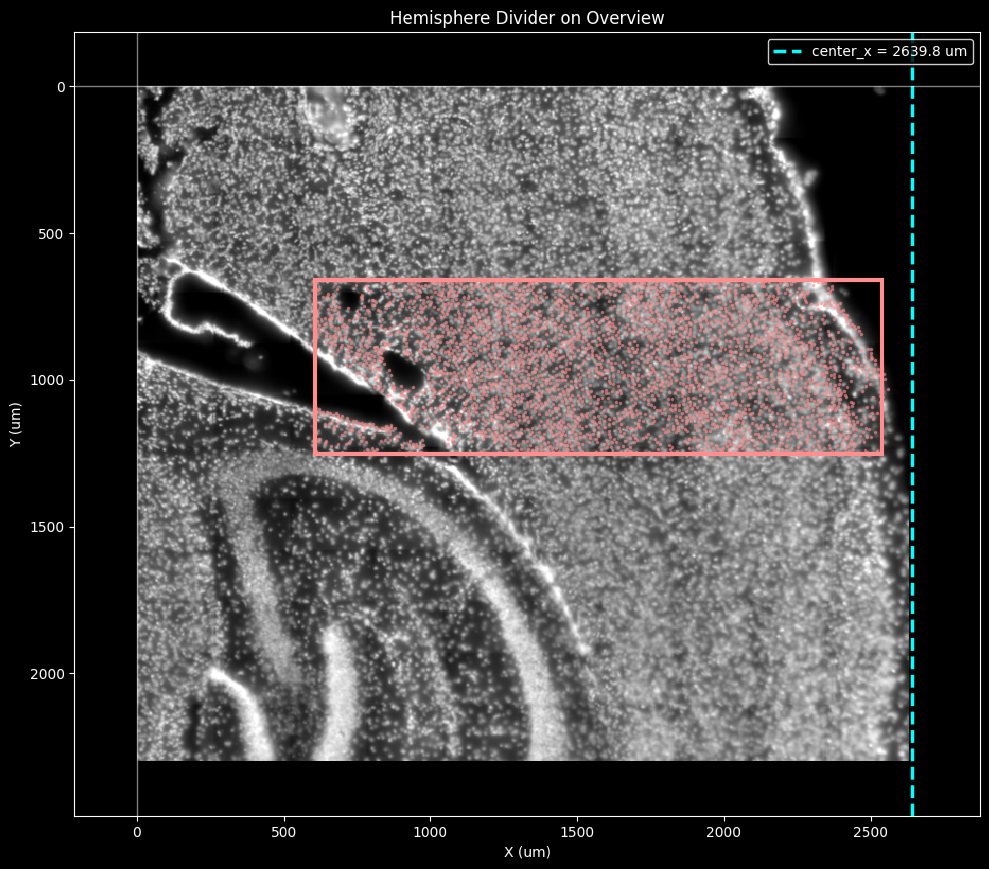

In [ ]:
# Change the center + offset here, rerun to preview
# --- Hemisphere divider in overview-micron space ---
# Tune in local overview frame, then mirror into global frame when flip_x is enabled.
# center_x_local = overview_width / 2       # use this for midline split
# center_x_local = -1                      # everything -> right hemisphere
center_x_local = overview_width + 1      # everything -> left hemisphere
center_x_offset = +10
center_x = flipCenterX(center_x_local + center_x_offset, overview_width, flip_x)

print(f"center_x_local = {center_x_local + center_x_offset:.1f} um")
print(f"center_x = {center_x:.1f} um  (overview width = {overview_width:.1f} um, flip_x={flip_x})")

# --- #

# Plot the hemisphere divider line on the overview with subregions
fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")
ax.set_facecolor("black")
overview_bounds = get_overview_plot_bounds()

ax.imshow(
    ov_display,
    cmap="gray",
    extent=(0.0, overview_width, overview_height, 0.0),
    interpolation="nearest",
)

n_subregions = len(RAW_CZI_SUBREGIONS)

# Plot cells in overview-global coords so this matches aggregate-on-overview QC
for i in range(n_subregions):
    sub_coords = adata[adata.obs["subregion_idx"] == i].obsm["spatial"].copy()
    scatter_color = get_subregion_hsl_color(i, n_subregions)
    ax.scatter(sub_coords[:, 0], sub_coords[:, 1], s=2, c=[scatter_color], alpha=0.5)

# Draw subregion boundaries
for i, entry in enumerate(transform_params["subregions"]):
    e = entry["extent_microns"]
    boundary_color = get_subregion_hsl_color(i, n_subregions)
    x0, x1 = flipRangeX(float(e["left"]), float(e["right"]), overview_width, flip_x)
    rect = Rectangle(
        (x0, e["top"]),
        x1 - x0,
        e["bottom"] - e["top"],
        fill=False,
        edgecolor=boundary_color,
        linewidth=3,
    )
    ax.add_patch(rect)

# Hemisphere divider
ax.axvline(center_x, color="cyan", linewidth=2.5, linestyle="--", label=f"center_x = {center_x:.1f} um")

# ax.set_xlim(overview_bounds["left"], overview_bounds["right"])
# ax.set_ylim(overview_bounds["bottom"], overview_bounds["top"])
ax.set_xlim(min(overview_bounds["left"], center_x - 20), max(overview_bounds["right"], center_x + 20))
ax.set_ylim(overview_bounds["bottom"], overview_bounds["top"])
ax.set_aspect("equal", "box")
ax.set_xlabel("X (um)")
ax.set_ylabel("Y (um)")
style_dark_axes(ax, "Hemisphere Divider on Overview", show_origin_axes=True)

pad_axes(fig, pad_fraction=0.08)

legend = ax.legend(loc="upper right")
style_dark_legend(legend)

plt.tight_layout()
plt.show()


In [ ]:
## IMPORTANT !!!!
## SET THE FOLLOWING FLAG TO TRUE ONCE YOU ARE HAPPY WITH THE ALIGNMENT ABOVE, THEN RE-RUN THIS CELL TO CONTINUE WITH THE ANALYSIS
MIDLINE_ALIGNED = False
assert MIDLINE_ALIGNED, "Set MIDLINE_ALIGNED = True once you are satisfied with the hemisphere midline alignment to continue"


### Load CCF `.flat` mask

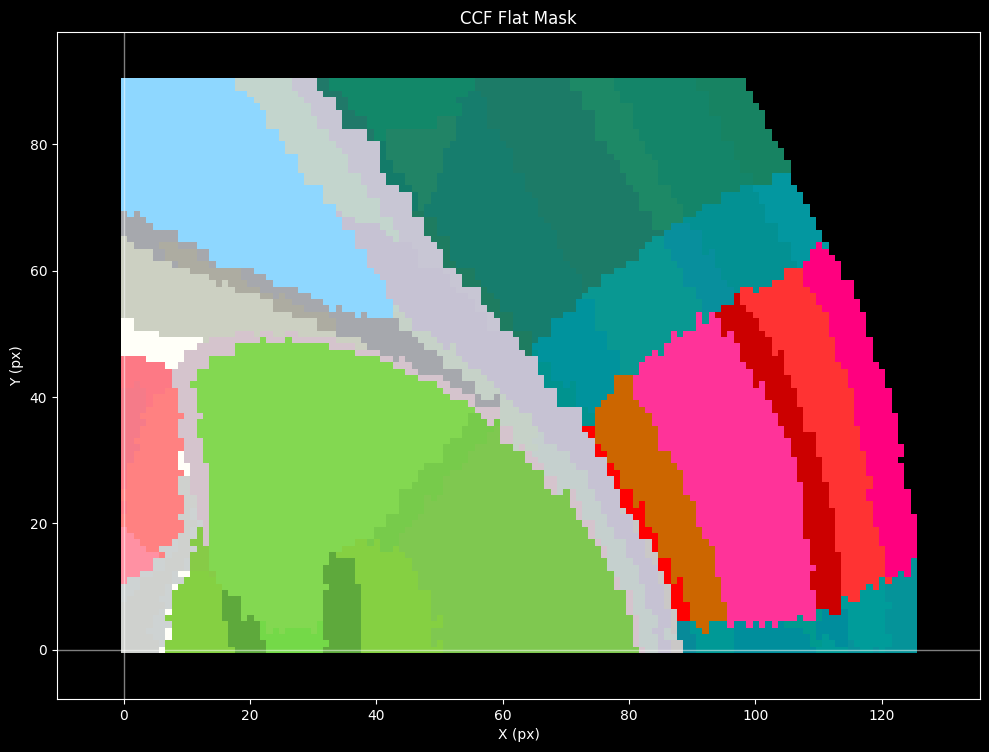

Mask shape: (91, 126)


In [17]:
mask_path = CCF_FLAT_OVERVIEW

with open(mask_path, 'rb') as f:
    buffer = f.read()
shape = np.frombuffer(buffer, dtype=np.dtype('>i4'), offset=1, count=2)
mask = np.frombuffer(buffer, dtype=np.dtype('>i2'), offset=9)
mask = mask.reshape(shape[::-1])
mask = mask[::-1]

# Remove all-empty rows and columns
mask = mask[~np.all(mask == 0, axis=1)]
mask = mask[:, ~np.all(mask == 0, axis=0)]

# Build RGB image from mask metadata
R = np.zeros(mask.shape, np.uint8)
G = np.zeros(mask.shape, np.uint8)
B = np.zeros(mask.shape, np.uint8)
for c in np.unique(mask):
    clr = mask_metadata[c]
    idx = mask == c
    R[idx] = clr['red']
    G[idx] = clr['green']
    B[idx] = clr['blue']
rgb = np.stack((R, G, B), axis=2)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(rgb)
ax.invert_yaxis()  # bottom-left origin
ax.set_xlabel("X (px)")
ax.set_ylabel("Y (px)")
style_dark_axes(ax, "CCF Flat Mask", show_origin_axes=True)
pad_axes(fig, pad_fraction=0.08)
plt.tight_layout()
plt.show()

print(f"Mask shape: {mask.shape}")

### Align Overview Image -> CCF Mask

Tune the parameters below so the overview image (rendered in grayscale with alpha) fits exactly on top of the CCF mask. The same transformation will later be applied to the AnnData coordinates.

**Tip:** First set `optional_scaling` to match the overall size, then tweak `x_stretch`/`y_stretch` for aspect ratio, then `data_x_offset`/`data_y_offset` for position.

Overview:  2629 × 2301  µm
CCF mask:  126 × 91  px
Auto-scale:  0.0395  (µm -> px)


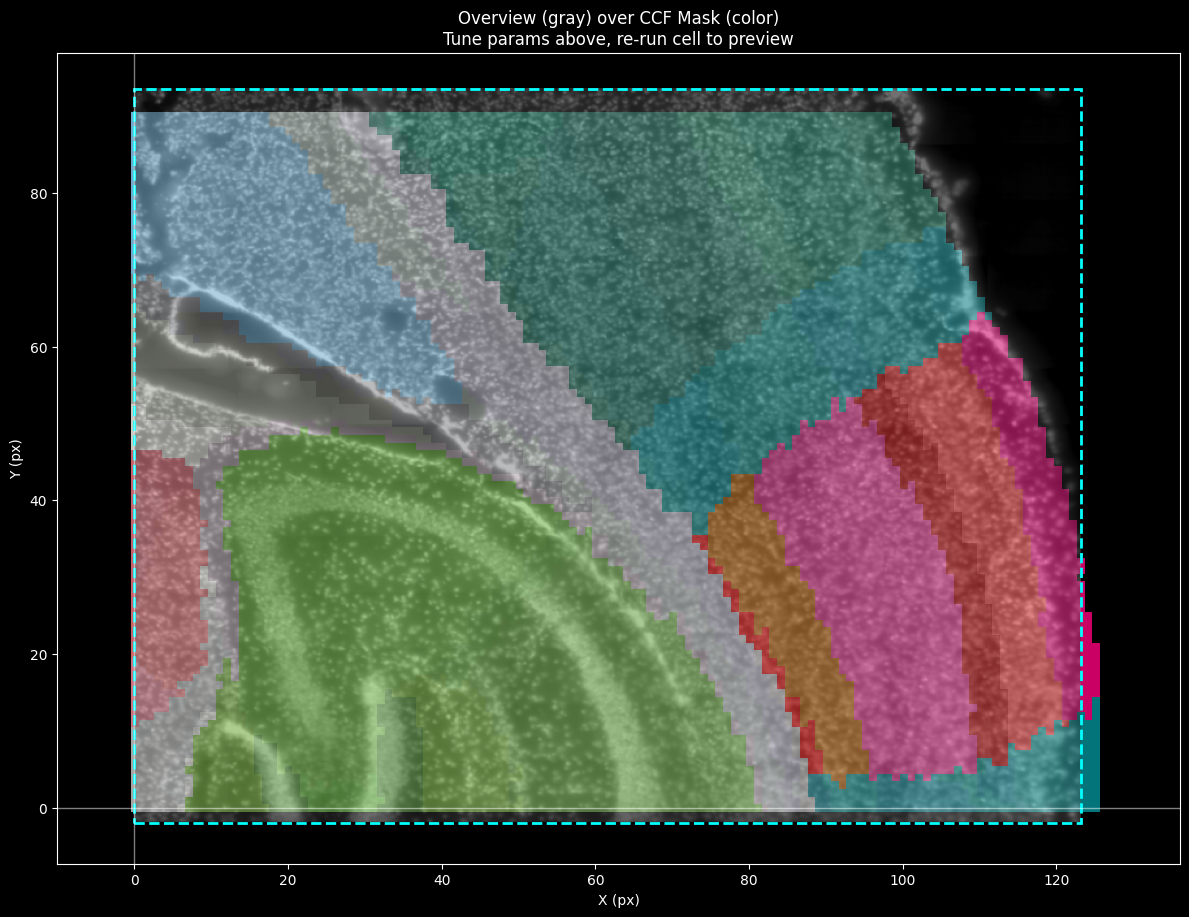

Final scale: 0.0395  |  Image size: 123 × 96 px
Offset: (0, -2)  |  Stretch: (1.185, 1.050)


In [18]:
# --- Tuning parameters (adjust these, then re-run this cell to preview) ---
data_x_offset = 0        # px, horizontal shift; positive -> right
data_y_offset = -2        # px, vertical shift; positive -> up
optional_scaling = 1   # >1 enlarges, <1 shrinks
x_stretch = 1.185          # horizontal stretch factor
y_stretch = 1.05          # vertical stretch factor

# --- #

# Overview dimensions (microns)
ov_w_microns = overview_width
ov_h_microns = overview_height

# Mask dimensions (pixels)
mask_w = mask.shape[1] # type: ignore
mask_h = mask.shape[0]

# --- Auto-scale: fit overview microns -> mask pixels, maintaining aspect ratio ---
scale1 = min(mask_w / ov_w_microns, mask_h / ov_h_microns)
scaled_w = ov_w_microns * scale1
scaled_h = ov_h_microns * scale1
scale2 = np.floor(mask_w / scaled_w) if scaled_w > 0 else 1.0
auto_scale = scale1 * scale2

print(f"Overview:  {ov_w_microns:.0f} × {ov_h_microns:.0f}  µm")
print(f"CCF mask:  {mask_w} × {mask_h}  px")
print(f"Auto-scale:  {auto_scale:.4f}  (µm -> px)")

# --- Final transform ---
final_scale = auto_scale * optional_scaling
img_w_px = ov_w_microns * final_scale * x_stretch
img_h_px = ov_h_microns * final_scale * y_stretch

# --- Enhance overview image for visibility ---
ov_img = overview_czi_data["xy_imgdata"].astype(np.float32) # type: ignore
ov_low, ov_high = np.percentile(ov_img, [3, 99.8])
ov_display = np.clip((ov_img - ov_low) / (ov_high - ov_low + 1e-12), 0.0, 1.0)

ov_display = np.power(ov_display, 0.5)  # gamma < 1 brightens dim areas; gamma > 1 darkens bright areas

# --- Plot: CCF mask (background) + overview image (alpha overlay) ---
fig, ax = plt.subplots(figsize=(12, 12))

# CCF mask as background
ax.imshow(rgb, origin="lower", alpha=0.8)

# Overview image overlaid with alpha
# origin="upper" keeps image upright (row 0 = tissue surface = high y)
left = data_x_offset
right = data_x_offset + img_w_px
bottom = data_y_offset
top = data_y_offset + img_h_px
ax.imshow(ov_display, cmap="gray", alpha=0.45, extent=(left, right, bottom, top), origin="upper")

# Draw the overview bounding box
rect = Rectangle(
    (left, bottom),
    img_w_px,
    img_h_px,
    fill=False,
    edgecolor="cyan",
    linewidth=2,
    linestyle="--",
)
ax.add_patch(rect)

ax.set_xlim(0, mask_w)
ax.set_ylim(0, mask_h)
ax.set_aspect("equal", "box")
ax.set_xlabel("X (px)")
ax.set_ylabel("Y (px)")
style_dark_axes(ax, "Overview (gray) over CCF Mask (color)\nTune params above, re-run cell to preview", show_origin_axes=True)
pad_axes(fig, pad_fraction=0.08)
plt.tight_layout()
plt.show()

print(f"Final scale: {final_scale:.4f}  |  Image size: {img_w_px:.0f} × {img_h_px:.0f} px")
print(f"Offset: ({data_x_offset}, {data_y_offset})  |  Stretch: ({x_stretch:.3f}, {y_stretch:.3f})")

In [ ]:
## IMPORTANT !!!!
## SET THE FOLLOWING FLAG TO TRUE ONCE YOU ARE HAPPY WITH THE ALIGNMENT ABOVE, THEN RE-RUN THIS CELL TO CONTINUE WITH THE ANALYSIS
CCF_ALIGNED = False
assert CCF_ALIGNED, "Set CCF_ALIGNED = True once you are satisfied with the overview to CCF mask alignment to continue"

### Apply Transform to AnnData Coordinates

Take the aggregated AnnData (in overview-micron space), apply the same scale/stretch/offset transform to map coordinates into CCF-mask pixel space.

Transformed 3041 cells to CCF mask pixel space
CCF coords range: X [28.6, 120.0], Y [41.6, 66.1]


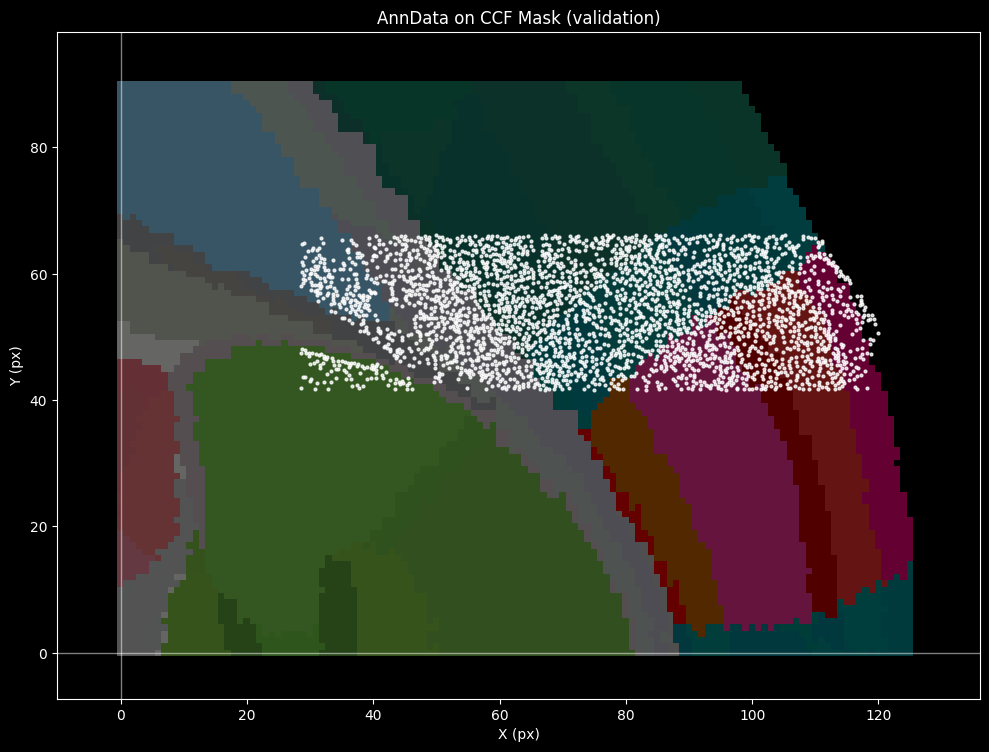

In [20]:
# --- Transform AnnData coordinates: overview-microns -> CCF-mask pixels ---
# Same transform pipeline: scale -> stretch -> offset

mask_coords = adata.obsm["spatial"].copy()

# 1. Scale (microns -> pixels)
mask_coords[:, 0] = mask_coords[:, 0] * final_scale
mask_coords[:, 1] = mask_coords[:, 1] * final_scale

# 2. Stretch
mask_coords[:, 0] = mask_coords[:, 0] * x_stretch
mask_coords[:, 1] = mask_coords[:, 1] * y_stretch

# 3. Offset
mask_coords[:, 0] = mask_coords[:, 0] + data_x_offset
mask_coords[:, 1] = mask_coords[:, 1] + data_y_offset

# Flip Y axis to match image origin
mask_coords[:, 1] = 2 * data_y_offset + img_h_px - mask_coords[:, 1]

adata.obsm["spatial_ccf"] = mask_coords

print(f"Transformed {adata.n_obs} cells to CCF mask pixel space")
print(f"CCF coords range: X [{mask_coords[:, 0].min():.1f}, {mask_coords[:, 0].max():.1f}], "
      f"Y [{mask_coords[:, 1].min():.1f}, {mask_coords[:, 1].max():.1f}]")

# --- Quick overlay: CCF mask + transformed AnnData scatter ---
fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")
ax.set_facecolor("black")
ax.imshow(rgb, origin="lower", alpha=0.4)
ax.scatter(mask_coords[:, 0], mask_coords[:, 1], s=4, c="white", alpha=0.8)
ax.set_xlim(0, mask_w)
ax.set_ylim(0, mask_h)
ax.set_aspect("equal", "box")
ax.set_xlabel("X (px)")
ax.set_ylabel("Y (px)")
style_dark_axes(ax, "AnnData on CCF Mask (validation)", show_origin_axes=True)
pad_axes(fig, pad_fraction=0.08)
plt.tight_layout()
plt.show()


### CCF Label Transfer to AnnData
For each target region in the CCF mask, determine which cells fall within the mask region, then assign left/right hemisphere labels based on `center_x`.

In [21]:
# CCF mask target indices to label (AUD regions)
# Adjust this range based on which CCF regions you want to extract
mask_target_indices = np.arange(138, 144)  # Primary auditory area layers 1-6a

# Show which regions will be labeled
for idx in mask_target_indices:
    name = mask_metadata.get(idx, {}).get('name', f'Unknown region {idx}') # type: ignore
    c = mask_metadata.get(idx, {}) # type: ignore
    r, g, b = c.get('red', 0), c.get('green', 0), c.get('blue', 0)
    print(f"  index {idx}: {name}  RGB({r},{g},{b})")
print(f"\nTotal: {len(mask_target_indices)} regions to label (×2 hemispheres = {len(mask_target_indices)*2} obs columns)")


  index 138: Primary auditory area, layer 1  RGB(255,0,127)
  index 139: Primary auditory area, layer 2/3  RGB(255,51,51)
  index 140: Primary auditory area, layer 4  RGB(204,0,0)
  index 141: Primary auditory area, layer 5  RGB(255,51,153)
  index 142: Primary auditory area, layer 6a  RGB(204,102,0)
  index 143: Primary auditory area, layer 6b  RGB(255,0,0)

Total: 6 regions to label (×2 hemispheres = 12 obs columns)


In [22]:
# =============================================================================
# Label Transfer: CCF mask -> AnnData.obs
# =============================================================================
# For each target CCF index, create a binary mask slice and check which cells
# fall inside it. Assign Left/Right based on center_x.
# =============================================================================

def rgb2Hex(r, g, b):
    """Convert RGB integers (0-255) to hex string."""
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

def hex2Rgb(hex_str):
    """Convert hex string to RGB tuple."""
    hex_str = hex_str.lstrip('#')
    return tuple(int(hex_str[i:i+2], 16) for i in (0, 2, 4))

def rgb2Hsv(r, g, b):
    """Convert RGB to HSV. r,g,b in 0-255."""
    r, g, b = r / 255.0, g / 255.0, b / 255.0
    mx = max(r, g, b)
    mn = min(r, g, b)
    df = mx - mn
    if mx == mn:
        h = 0
    elif mx == r:
        h = (60 * ((g - b) / df) + 360) % 360
    elif mx == g:
        h = (60 * ((b - r) / df) + 120) % 360
    elif mx == b:
        h = (60 * ((r - g) / df) + 240) % 360
    else:
        h = 0
    s = 0 if mx == 0 else df / mx
    v = mx
    return h, s, v

def hsv2Rgb(h, s, v):
    """Convert HSV to RGB (0-255)."""
    h = h % 360
    c = v * s
    x = c * (1 - abs((h / 60) % 2 - 1))
    m = v - c
    if 0 <= h < 60:
        r, g, b = c, x, 0
    elif 60 <= h < 120:
        r, g, b = x, c, 0
    elif 120 <= h < 180:
        r, g, b = 0, c, x
    elif 180 <= h < 240:
        r, g, b = 0, x, c
    elif 240 <= h < 300:
        r, g, b = x, 0, c
    elif 300 <= h < 360:
        r, g, b = c, 0, x
    else:
        r, g, b = 0, 0, 0
    r, g, b = (r + m) * 255, (g + m) * 255, (b + m) * 255
    return int(r), int(g), int(b)

def hueShift(hex_color, degree):
    """Shift the hue of a hex color by a given number of degrees."""
    r, g, b = hex2Rgb(hex_color)
    h, s, v = rgb2Hsv(r, g, b)
    h = (h + degree) % 360
    r, g, b = hsv2Rgb(h, s, v)
    return rgb2Hex(r, g, b)


# We work on a copy so the original adata stays clean
roi_labeled_adata = adata.copy()
mask_coords = roi_labeled_adata.obsm["spatial_ccf"]

# For label transfer, use center_x in overview-micron space, but transform it to CCF pixel space
# Scale it the same way: scale -> stretch -> offset
center_x_ccf = center_x * final_scale * x_stretch + data_x_offset

for idx in mask_target_indices:
    # Build binary mask for this CCF region
    mask_target = (mask == idx).astype(np.uint8)
    data_masked = np.zeros(len(mask_coords), dtype=bool)

    for i, coord in enumerate(mask_coords):
        x = int(np.round(coord[0])) # type: ignore
        y = int(np.round(coord[1])) # type: ignore
        if x < 0 or y < 0 or x >= mask_target.shape[1] or y >= mask_target.shape[0]:
            continue
        if mask_target[y, x] == 1:
            data_masked[i] = True

    region_name = mask_metadata.get(idx, {}).get("name", f"Unknown region {idx}") # type: ignore
    base_color = rgb2Hex(
        mask_metadata.get(idx, {}).get("red", 0), # type: ignore
        mask_metadata.get(idx, {}).get("green", 0), # type: ignore
        mask_metadata.get(idx, {}).get("blue", 0), # type: ignore
    )

    # Left / Right assignment based on center_x_ccf
    if not invert_hemi_labels:
        roi_labeled_adata.obs[f"ROI__Left {region_name}"] = data_masked & (mask_coords[:, 0] <= center_x_ccf)
        roi_labeled_adata.obs[f"ROI__Right {region_name}"] = data_masked & (mask_coords[:, 0] > center_x_ccf)
    else:
        roi_labeled_adata.obs[f"ROI__Left {region_name}"] = data_masked & (mask_coords[:, 0] > center_x_ccf)
        roi_labeled_adata.obs[f"ROI__Right {region_name}"] = data_masked & (mask_coords[:, 0] <= center_x_ccf)

    # Build ROI metadata (color-coded; left hemisphere gets a hue-shifted color)
    if "obs_roi_metadata" not in roi_labeled_adata.uns:
        roi_labeled_adata.uns["obs_roi_metadata"] = {}

    roi_labeled_adata.uns["obs_roi_metadata"][f"ROI__Left {region_name}"] = {
        "name": f"Left {region_name}",
        "color": hueShift(base_color, 200),
        "index": idx,
    }
    roi_labeled_adata.uns["obs_roi_metadata"][f"ROI__Right {region_name}"] = {
        "name": f"Right {region_name}",
        "color": base_color,
        "index": idx,
    }

# Summarize
roi_obs_names = [
    f"ROI__{side} {mask_metadata.get(idx, {}).get('name', f'Unknown region {idx}')}" # type: ignore
    for side in ("Left", "Right")
    for idx in mask_target_indices
]
print(f"Labeled {len(roi_obs_names)} ROI columns in .obs")
for name in roi_obs_names:
    count = roi_labeled_adata.obs[name].sum()
    print(f"  {name}: {count} cells")

Labeled 12 ROI columns in .obs
  ROI__Left Primary auditory area, layer 1: 131 cells
  ROI__Left Primary auditory area, layer 2/3: 275 cells
  ROI__Left Primary auditory area, layer 4: 99 cells
  ROI__Left Primary auditory area, layer 5: 219 cells
  ROI__Left Primary auditory area, layer 6a: 9 cells
  ROI__Left Primary auditory area, layer 6b: 0 cells
  ROI__Right Primary auditory area, layer 1: 0 cells
  ROI__Right Primary auditory area, layer 2/3: 0 cells
  ROI__Right Primary auditory area, layer 4: 0 cells
  ROI__Right Primary auditory area, layer 5: 0 cells
  ROI__Right Primary auditory area, layer 6a: 0 cells
  ROI__Right Primary auditory area, layer 6b: 0 cells


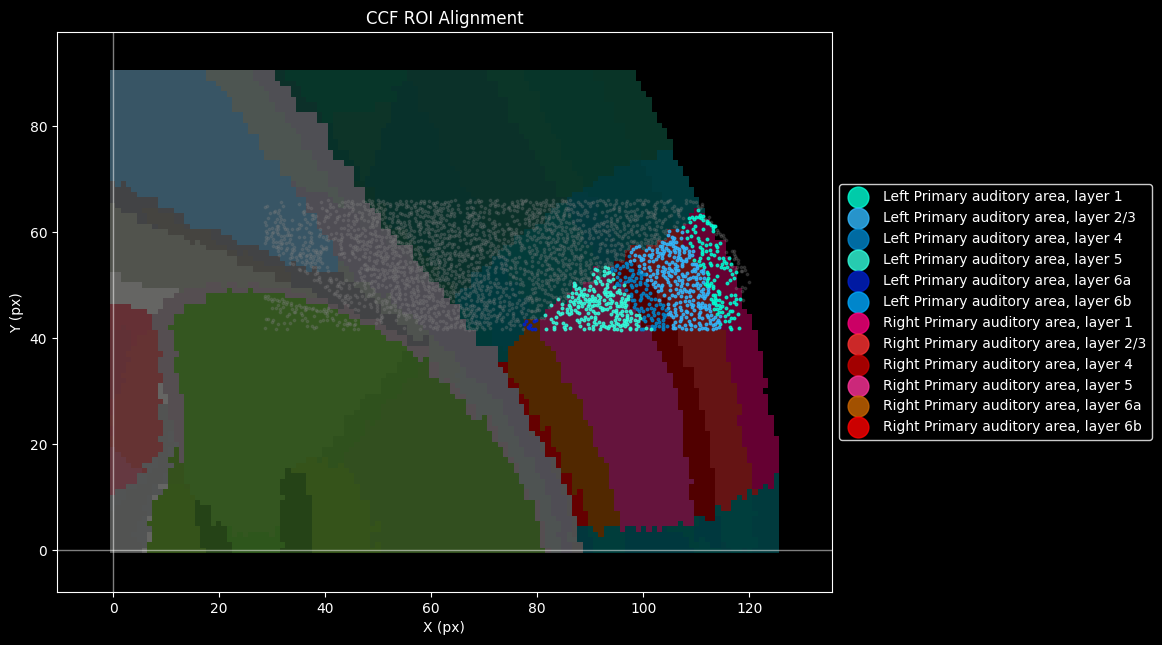

Saved validation plot to: D:/JOBS/WashU_Neuroscience/RNAScope/RNAScope_DATA/TEST_ACxDev1_CBA-CAJ_P18_Male_LACx_ONLY/data\..\analysis\CCF_ROI_Alignment.png


In [23]:
# =============================================================================
# Validation Plot: CCF mask + ROI-labeled cells
# =============================================================================

roi_obs_names = [
    f"ROI__{side} {mask_metadata.get(idx, {}).get('name', f'Unknown region {idx}')}" # type: ignore
    for side in ("Left", "Right")
    for idx in mask_target_indices
]

fig, ax = plt.subplots(figsize=(10, 10))

# CCF mask as faint background
ax.imshow(rgb, origin="lower", alpha=0.4)

# Plot each ROI in its assigned color
for roi_name in roi_obs_names:
    data = roi_labeled_adata[roi_labeled_adata.obs[roi_name] == True]
    roi_meta = roi_labeled_adata.uns["obs_roi_metadata"]
    coords_roi = data.obsm["spatial_ccf"]
    ax.scatter(
        coords_roi[:, 0],
        coords_roi[:, 1],
        s=3.5,
        alpha=0.8,
        c=[roi_meta[roi_name]["color"]],
        label=roi_meta[roi_name]["name"],
    )

# The rest of the cells (not in any ROI) in gray
mask_any_roi = roi_labeled_adata.obs[roi_obs_names].any(axis=1) # type: ignore
other_cells = roi_labeled_adata[~mask_any_roi]
other_coords = other_cells.obsm["spatial_ccf"]
ax.scatter(other_coords[:, 0], other_coords[:, 1], s=3, c="gray", alpha=0.25)

ax.set_xlabel("X (px)")
ax.set_ylabel("Y (px)")
ax.set_aspect("equal", "box")
style_dark_axes(ax, "CCF ROI Alignment", show_origin_axes=True)
pad_axes(fig, pad_fraction=0.08)
legend = ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), markerscale=8)
style_dark_legend(legend)

save_plot_path = os.path.join(OUTPUT_DIR, "CCF_ROI_Alignment.png")
plt.savefig(save_plot_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Saved validation plot to: {save_plot_path}")

In [24]:
# =============================================================================
# Save CCF-labeled AnnData
# =============================================================================

# Make the output file name from OUTPUT_HDF5:
# add hdf5 ext if missing, and if the basename does not end with "_withCCF", add that too before the ext
output_hdf5 = OUTPUT_HDF5
loc = os.path.dirname(output_hdf5)
basename = os.path.basename(output_hdf5)
if not basename.endswith(".hdf5"):
    basename += ".hdf5"
if not basename.endswith("_withCCF.hdf5"):
	basename = basename.replace(".hdf5", "_withCCF.hdf5")
output_hdf5 = os.path.join(loc, basename)

roi_labeled_adata.write_h5ad(output_hdf5)
print(f"Saved CCF-labeled AnnData ({roi_labeled_adata.n_obs} cells) to: {output_hdf5}")

Saved CCF-labeled AnnData (3041 cells) to: D:/JOBS/WashU_Neuroscience/RNAScope/RNAScope_DATA/TEST_ACxDev1_CBA-CAJ_P18_Male_LACx_ONLY/data\..\analysis\RNAScope_CBA-CAJ_P18_Male_withCCF.hdf5
